# Project Description
   This project aims to develop machine learning models to predict individuals’ monthly income and classify them into income brackets based on demographic and financial-related features. Multiple regression and classification algorithms were applied to identify the most accurate and reliable models for both prediction and categorization tasks.

   The results of this project can support data-driven decision-making in areas such as financial assessment, socioeconomic analysis, and targeted policy or business strategies by providing insights into income prediction and classification.

   For more information on the dataset, columns, and data gathered, refer to the link attached:

[Default of Filipino Family Income and Expenditure Dataset](https://www.kaggle.com/datasets/grosvenpaul/family-income-and-expenditure)

**Table of Contents**

1. [Initial Look at the Data](#i)
2. [Data Cleaning](#dc)
3. [Train Test Split](#ts)
4. [Exploratory Data Analysis](#eda)
5. [Data Preprocessing](#dp)
6. [Model Selection / Deployment](#ms)
7. [Conclusion](#con)

# Initial Look at the Data <a name='i'></a>

In [60]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [61]:
# Loading Data

import zipfile as zf
zip_file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/archive.zip' #r for read; current file
extracted_file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/' #remove file name archive.zip

In [62]:
# Extracting of File

with zf.ZipFile(zip_file_path) as zip_reference:
  zip_reference.extractall(extracted_file_path)

In [63]:
# Loading the csv File

file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/Family Income and Expenditure.csv'

In [64]:
df = pd.read_csv(file_path)

In [65]:
df.head(2)

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2


In [66]:
df.tail(2)

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0
41543,128598,XII - SOCCSKSARGEN,78195,Enterpreneurial Activities,1,43485,41205,1985,7735,2062,...,0,0,0,0,0,1,0,0,0,0


In [67]:
# Renaming Columns "Total Household Income" to "Annual Household Income" for the sake of clarity

df.rename(columns={'Total Household Income':'Annual Household Income'}, inplace = True)

In [68]:
# Defining Income Brackets for later usage in the Classification Model

df['Monthly Income'] = df['Annual Household Income']/12
df['Income Brackets'] = pd.cut(df['Monthly Income'],
                               bins= [0, 11_000, 22_000, 44_000,
                                      77_000, 131_000, 219_000,
                                      999999999999999],
                               labels = ['Poor', 'Low Income', 'Lower Middle',
                                         'Middle Income', 'Upper Middle', 'Upper Middle not Rich',
                                         'Rich'])

In [69]:
df['Income Brackets'] = df['Income Brackets'].astype(str)

In [70]:
df.shape

(41544, 62)

In [71]:
df[['Region', 'Monthly Income', 'Income Brackets']].head(10)

,Region,Monthly Income,Income Brackets
0,CAR,40027.666667,Lower Middle
1,CAR,16519.583333,Low Income
2,CAR,6898.750000,Poor
3,CAR,8965.750000,Poor
4,CAR,15776.833333,Low Income
5,CAR,12740.250000,Low Income
6,CAR,16551.750000,Low Income
7,CAR,11246.750000,Low Income
8,CAR,14262.666667,Low Income
9,CAR,52146.083333,Middle Income


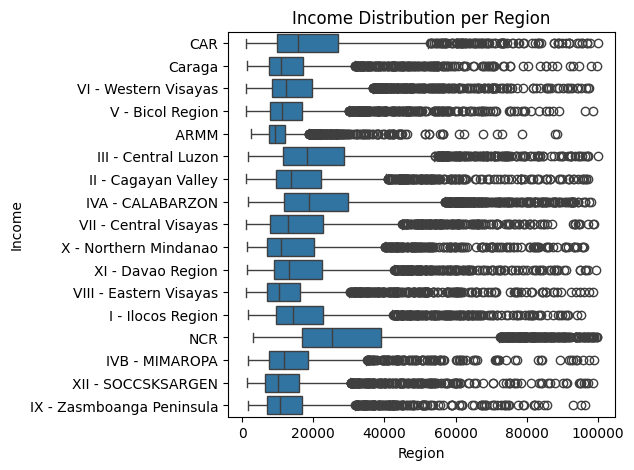

In [72]:
#  Inocme Distribution by Region

filt = df['Monthly Income'] < 100_000
df_filtered = df[filt]

plt.figure(figsize= (5,5))
sns.boxplot(data=df_filtered, y = 'Region', x= 'Monthly Income')
plt.title('Income Distribution per Region')
plt.xlabel('Region')
plt.ylabel('Income')
plt.show()

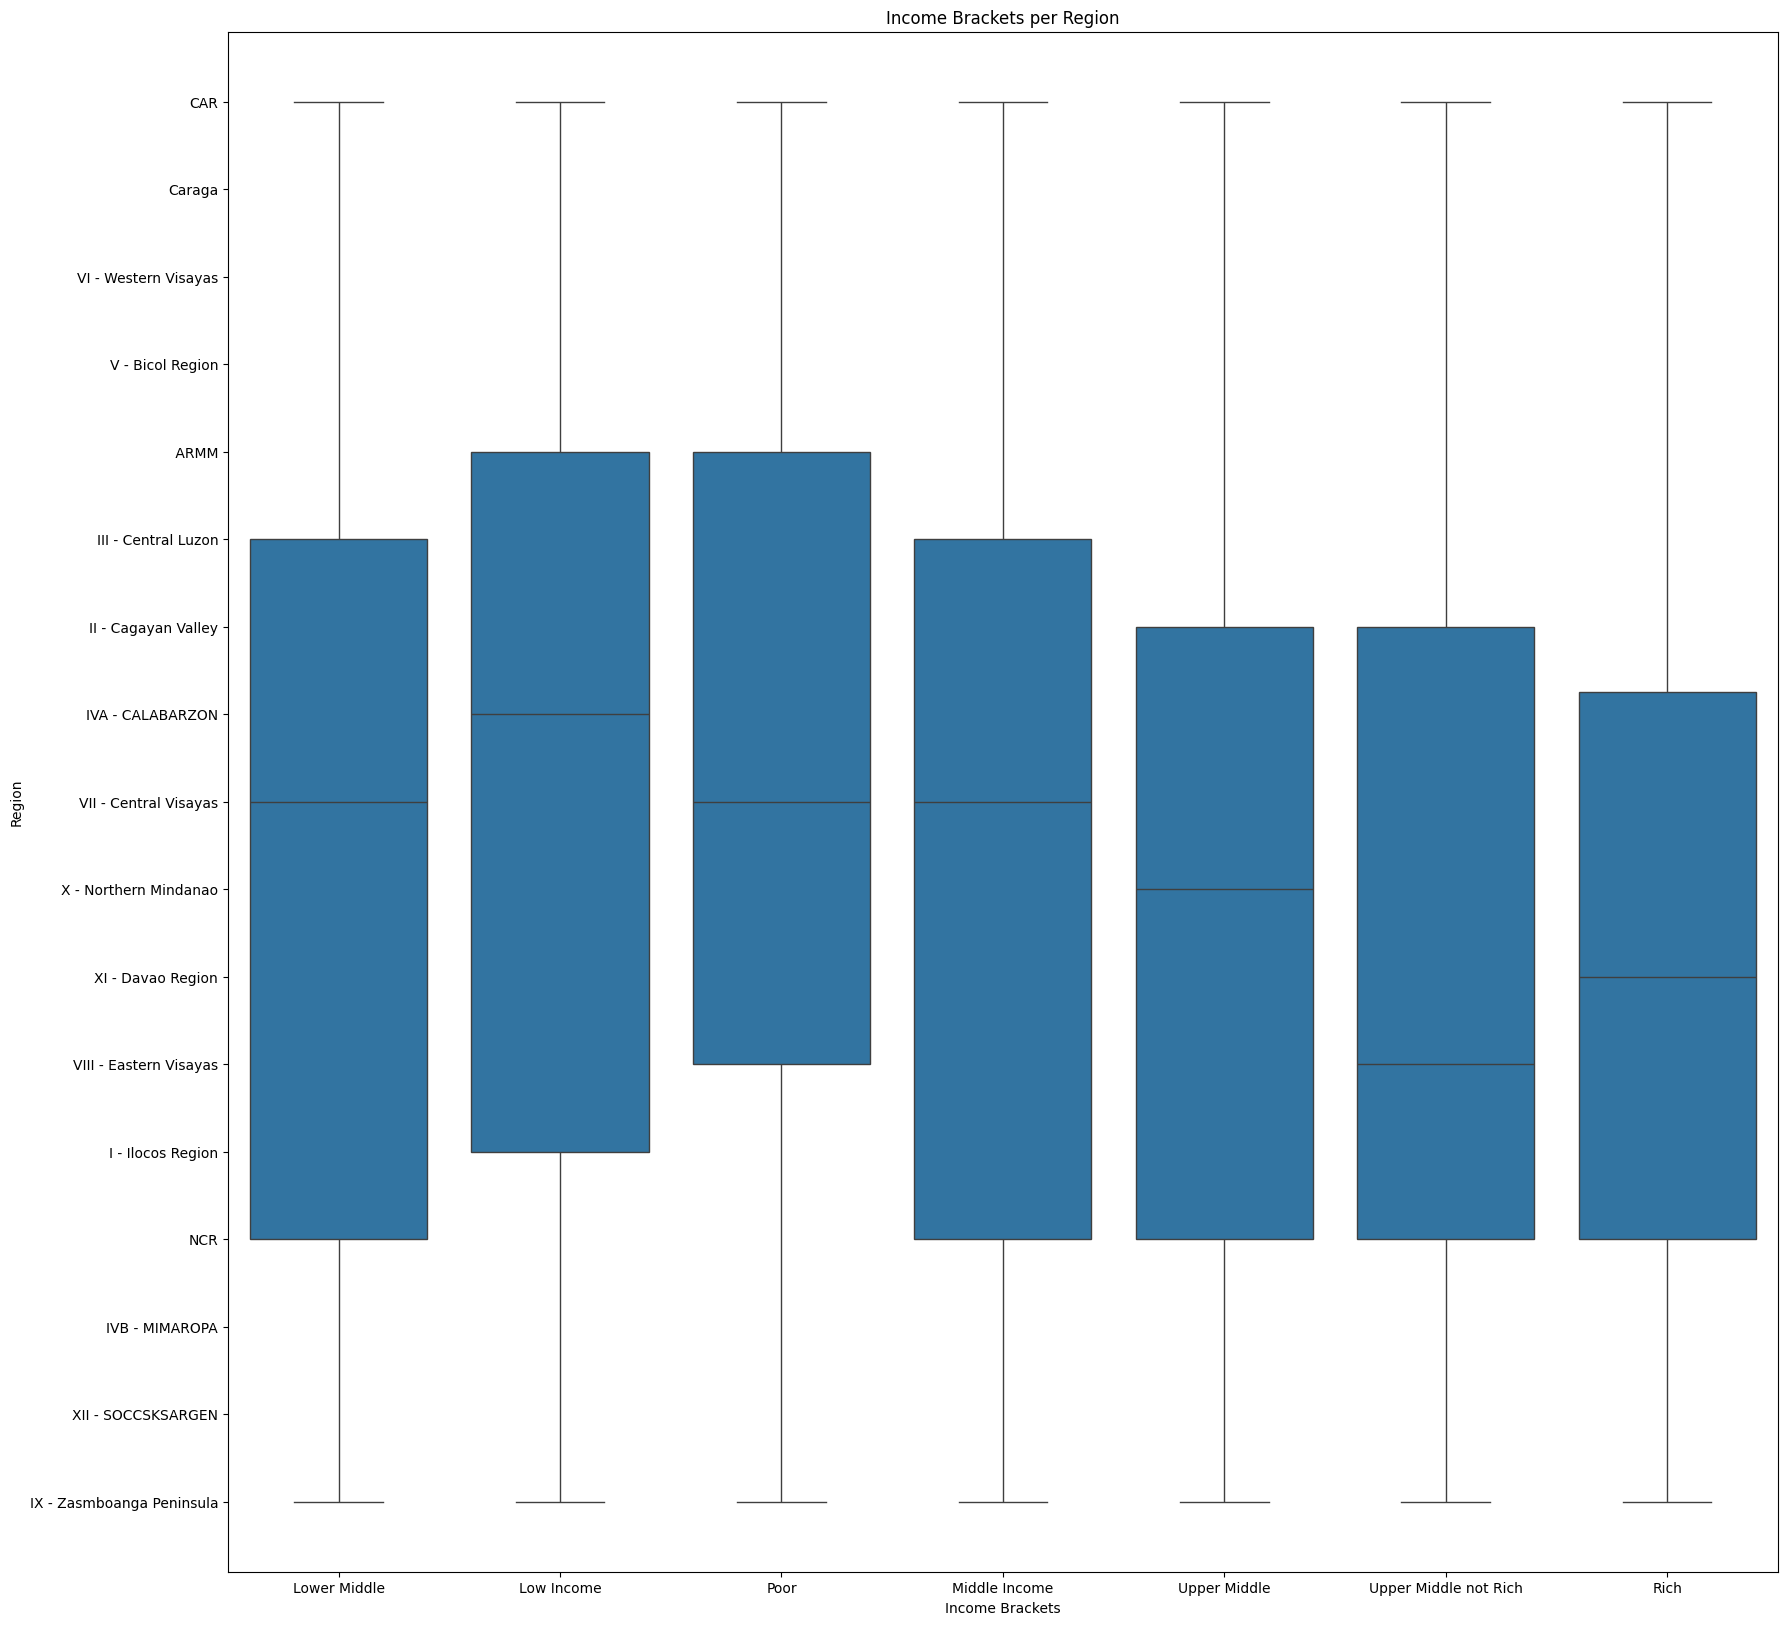

In [73]:
# Region by Income Brackets

plt.figure(figsize= (20,20))
sns.boxplot(data=df, y = 'Region', x= 'Income Brackets')
plt.title('Income Brackets per Region')
plt.xlabel('Income Brackets')
plt.ylabel('Region')
plt.show()

**Insights from the initial look at the dataset**

# Data Cleaning <a name='dc'></a>


In [74]:
# Clean column names
df.columns = df.columns.str.strip()

In [75]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0] / len(df)

,0
Household Head Class of Worker,0.181398
Household Head Occupation,0.181398
Toilet Facilities,0.038032


In [76]:
# Drop critical missing values

df_copy = df.drop(columns =['Household Head Occupation', 'Household Head Class of Worker'])

In [77]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Annual Household Income                        41544 non-null  int64  
 1   Region                                         41544 non-null  object 
 2   Total Food Expenditure                         41544 non-null  int64  
 3   Main Source of Income                          41544 non-null  object 
 4   Agricultural Household indicator               41544 non-null  int64  
 5   Bread and Cereals Expenditure                  41544 non-null  int64  
 6   Total Rice Expenditure                         41544 non-null  int64  
 7   Meat Expenditure                               41544 non-null  int64  
 8   Total Fish and  marine products Expenditure    41544 non-null  int64  
 9   Fruit Expenditure                              415

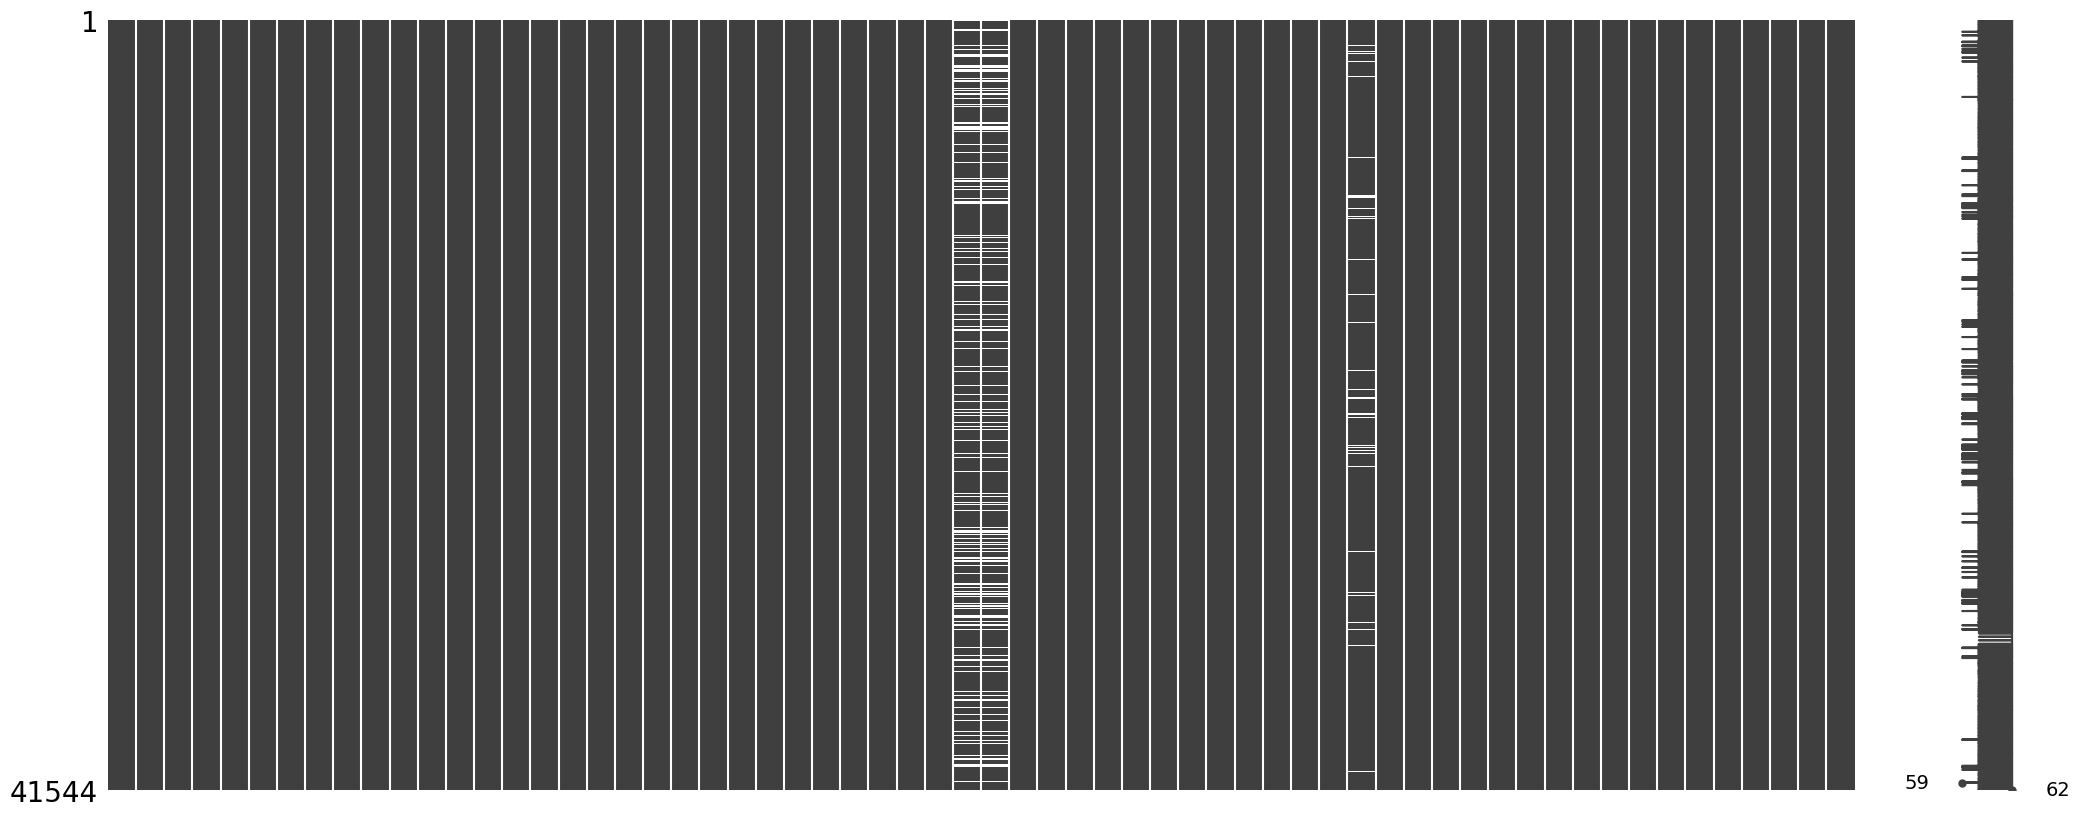

In [78]:
import missingno as msno
msno.matrix(df)
plt.show()

**Removing Outliers**

In [79]:
def outlier_remover(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr

  filt = (df[col] > lower) & (df[col] < upper)
  df = df[filt]

  return df

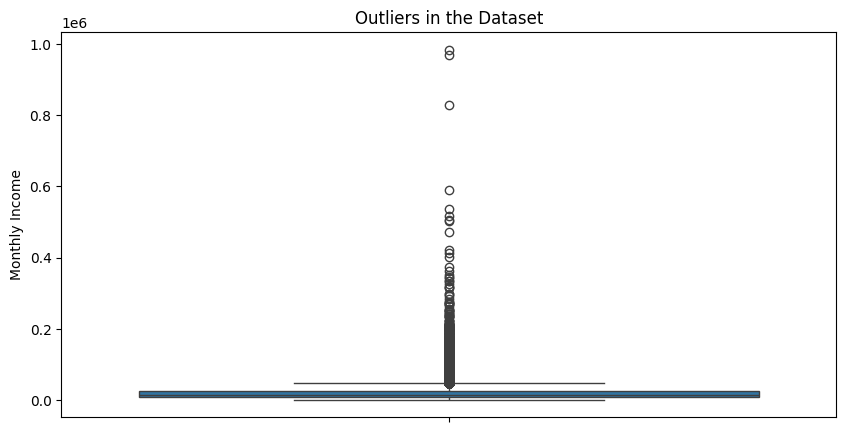

In [80]:
fig, axs = plt.subplots(figsize=(10, 5))
sns.boxplot(df['Monthly Income'])
plt.title('Outliers in the Dataset')
plt.show()

# Train Test Split <a mame='ts'></a>


In [81]:
y = df['Income Brackets']
x = df.drop(columns=['Monthly Income', 'Annual Household Income', 'Income Brackets'])
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2
                                        , stratify= y, random_state=42)

# Exploratory Data Analysis <a name='eda'></a>

**Let us compare the income from Top (3) Rural and Urban Regions for this Exploratory Analysis**

In [83]:
# FILTER FOR TOP 3 URBAN AND RURAL

urban_regions = ['NCR', 'IVA - CALABARZON', 'VII - Central Visayas']
rural_regions = ['II - Cagayan Valley', 'V - Bicol Region', 'VIII - Eastern Visayas']

df_urban = df[df['Region'].isin(urban_regions)]
df_rural = df[df['Region'].isin(rural_regions)]

In [84]:
# Creating a filter for my Combined Rural and Urban Regions

urban_regions = ['NCR', 'IVA - CALABARZON', 'VII - Central Visayas']
rural_regions = ['II - Cagayan Valley', 'V - Bicol Region', 'VIII - Eastern Visayas']

all_regions = urban_regions + rural_regions

filtered_regions = df[df['Region'].isin(all_regions)].copy()

region_type = {
'NCR': 'Urban',
'IVA - CALABARZON': 'Urban',
'VII - Central Visayas': 'Urban',

'II - Cagayan Valley': 'Rural',
'V - Bicol Region': 'Rural',
'VIII - Eastern Visayas': 'Rural'
}

filtered_regions['Urban_Rural'] = filtered_regions['Region'].map(region_type)

In [85]:
# Calculate Total Expenditure for filtered_regions
filtered_regions['Total Expenditure'] = filtered_regions['Total Food Expenditure'] + filtered_regions['Alcoholic Beverages Expenditure'] + \
                          filtered_regions['Restaurant and hotels Expenditure'] + filtered_regions['Tobacco Expenditure'] + \
                          filtered_regions['Clothing, Footwear and Other Wear Expenditure'] + filtered_regions['Housing and water Expenditure'] + \
                          filtered_regions['Medical Care Expenditure'] + filtered_regions['Transportation Expenditure'] + filtered_regions['Communication Expenditure'] + \
                          filtered_regions['Education Expenditure'] + filtered_regions['Miscellaneous Goods and Services Expenditure'] + filtered_regions['Special Occasions Expenditure'] + \
                          filtered_regions['Crop Farming and Gardening expenses'] + filtered_regions['Imputed House Rental Value']

# Calculate Monthly Expenditure for filtered_regions
filtered_regions['Monthly Expenditure'] = filtered_regions['Total Expenditure'] / 12

# Calculate Monthly Income for filtered_regions
filtered_regions['Monthly Income'] = filtered_regions['Annual Household Income']/12

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 62 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Annual Household Income                        41544 non-null  int64  
 1   Region                                         41544 non-null  object 
 2   Total Food Expenditure                         41544 non-null  int64  
 3   Main Source of Income                          41544 non-null  object 
 4   Agricultural Household indicator               41544 non-null  int64  
 5   Bread and Cereals Expenditure                  41544 non-null  int64  
 6   Total Rice Expenditure                         41544 non-null  int64  
 7   Meat Expenditure                               41544 non-null  int64  
 8   Total Fish and  marine products Expenditure    41544 non-null  int64  
 9   Fruit Expenditure                              415

In [87]:

df['Total Expenditure'] = df['Total Food Expenditure'] + df['Alcoholic Beverages Expenditure'] + \
                          df['Restaurant and hotels Expenditure'] + df['Tobacco Expenditure'] + \
                          df['Clothing, Footwear and Other Wear Expenditure'] + df['Housing and water Expenditure'] + \
                          df['Medical Care Expenditure'] + df['Transportation Expenditure'] + df['Communication Expenditure'] + \
                          df['Education Expenditure'] + df['Miscellaneous Goods and Services Expenditure'] + df['Special Occasions Expenditure'] + \
                          df['Crop Farming and Gardening expenses'] + df['Imputed House Rental Value']

In [88]:
# to make the total expenditure into monthly

df['Monthly Expenditure'] = df['Total Expenditure'] / 12

In [89]:
# to make total income into monthly

df['Monthly Income'] = df['Annual Household Income']/12

**Reflecting the Monthly Income vs Monthly Expenditure**


In [90]:
region_table = filtered_regions.groupby(['Urban_Rural', 'Region'])[['Monthly Income','Monthly Expenditure']].mean().round(2)
region_table

Monthly Income  Monthly Expenditure
Urban_Rural Region                                                     
Rural       II - Cagayan Valley           19731.52             17960.47
            V - Bicol Region              15508.79             15213.65
            VIII - Eastern Visayas        16394.72             14113.35
Urban       IVA - CALABARZON              25280.04             24319.98
            NCR                           35071.82             33709.61
            VII - Central Visayas         19575.78             18139.27

In [91]:
# Including the percetage per recommendation

filtered_regions['% Income Spent'] = (filtered_regions['Monthly Expenditure']/filtered_regions['Monthly Income']) * 100

filtered_regions['% Income Saved'] = 100 - filtered_regions['% Income Spent']

In [92]:
region_table = filtered_regions.groupby(['Urban_Rural', 'Region'])[['Monthly Income','Monthly Expenditure','% Income Spent','% Income Saved']].mean().round(2)
region_table

Monthly Income  Monthly Expenditure  \
Urban_Rural Region                                                        
Rural       II - Cagayan Valley           19731.52             17960.47   
            V - Bicol Region              15508.79             15213.65   
            VIII - Eastern Visayas        16394.72             14113.35   
Urban       IVA - CALABARZON              25280.04             24319.98   
            NCR                           35071.82             33709.61   
            VII - Central Visayas         19575.78             18139.27   

                                    % Income Spent  % Income Saved  
Urban_Rural Region                                                  
Rural       II - Cagayan Valley             101.53           -1.53  
            V - Bicol Region                109.32           -9.32  
            VIII - Eastern Visayas          101.17           -1.17  
Urban       IVA - CALABARZON                106.51           -6.51  
            NCR                             105.00           -5.00  
            VII - Central Visayas           112.85          -12.85

In [93]:
region_table_reset = region_table.reset_index()

region_melt = region_table_reset.melt(
    id_vars=['Urban_Rural','Region'],
    value_vars=['Monthly Income','Monthly Expenditure'],
    var_name='Category',
    value_name='Amount'
)

**Monthly Income vs Monthly Expenditure by Region**

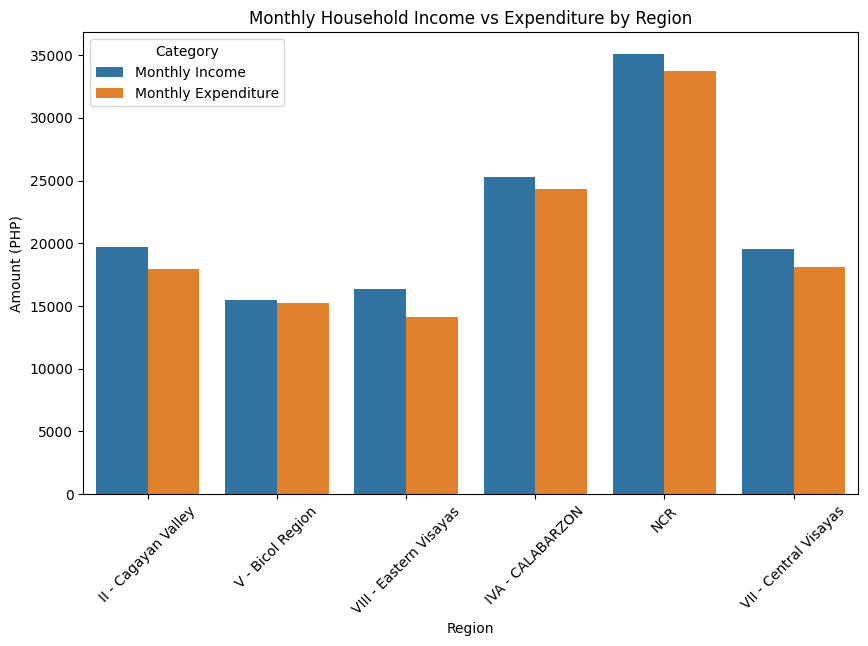

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(data=region_melt, x='Region', y='Amount', hue='Category')

plt.title('Monthly Household Income vs Expenditure by Region')
plt.xlabel('Region')
plt.ylabel('Amount (PHP)')
plt.xticks(rotation=45)

plt.show()

**Insights**

  1. Urban regions show higher household income.
  2. Expenditures closely follow income levels.
  3. NCR has the highest income and spending.
  4. Limited savings capacity across regions.
  5. Rural regions have lower income levels.

 **Percentage of Household Income Spent vs Saved by Region**

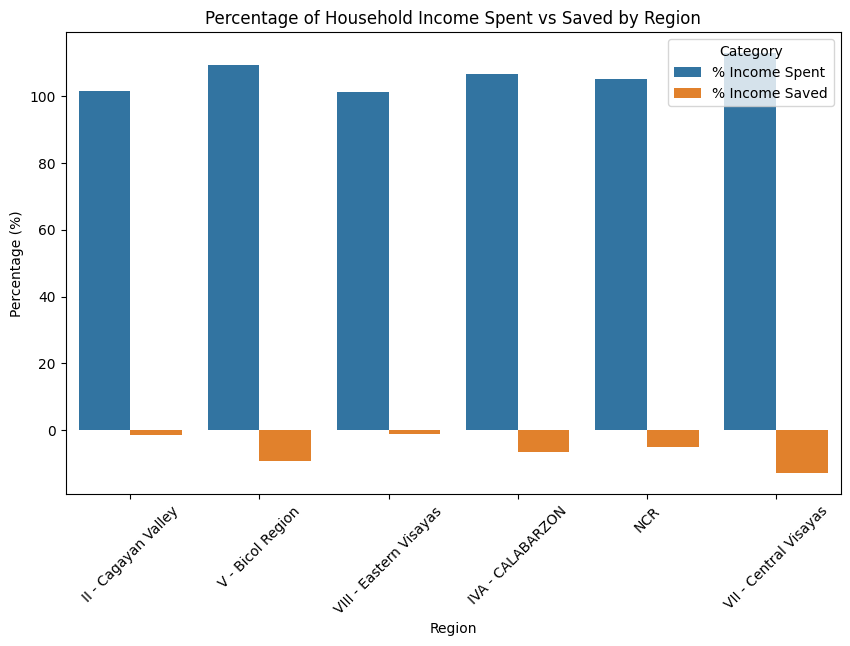

In [36]:
region_table_reset = region_table.reset_index()

percent_melt = region_table_reset.melt(
    id_vars=['Urban_Rural','Region'],
    value_vars=['% Income Spent', '% Income Saved'],
    var_name='Category',
    value_name='Percentage'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=percent_melt,
    x='Region',
    y='Percentage',
    hue='Category'
)

plt.title('Percentage of Household Income Spent vs Saved by Region')
plt.ylabel('Percentage (%)')
plt.xlabel('Region')

plt.xticks(rotation=45)

plt.show()



**Rural vs Urban on Income Spent vs Income Saved**

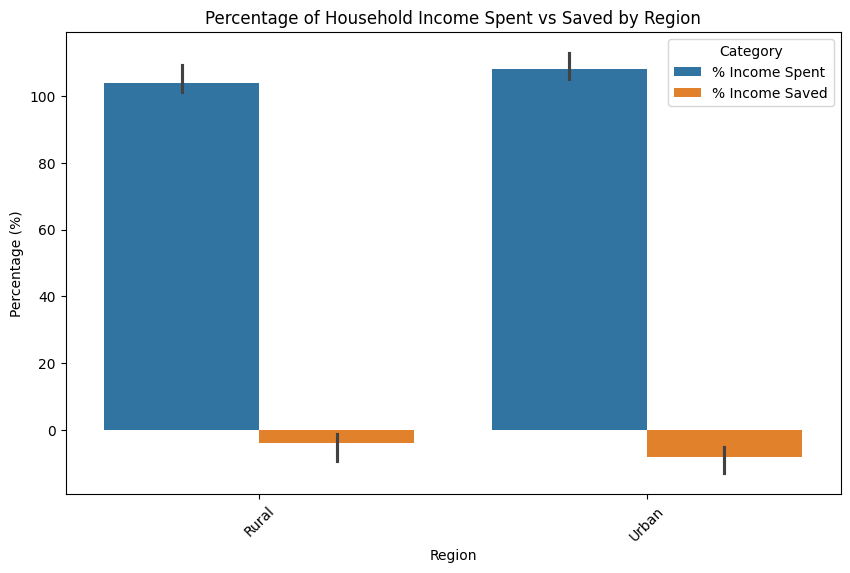

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=percent_melt,
    x='Urban_Rural',
    y='Percentage',
    hue='Category'
)

plt.title('Percentage of Household Income Spent vs Saved by Region')
plt.ylabel('Percentage (%)')
plt.xlabel('Region')

plt.xticks(rotation=45)

plt.show()

**Insights**

  1. Households spend most of their income.
  2. Negative savings appear in several regions.
  3. Rural regions show higher financial pressure.
  4. Urban regions still have limited savings.
  5. Both regions experience limited savings capacity, with expenditures consuming nearly all household income.


# Data Preprocessing <a name='dp'></a>

In [38]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

In [39]:
# One hot encoding to categorical columns
cat_cols = df.select_dtypes(include='object').columns

In [40]:
from sklearn.preprocessing import StandardScaler
num_cols = df.select_dtypes(include = ['float', 'int']).columns

In [41]:
scaler = StandardScaler()
for num_col in num_cols:
  x = df[[num_col]]
  df[num_col] = scaler.fit_transform(x)

In [42]:
x = x.select_dtypes(exclude=['object'])

In [43]:
# Identify categorical and numerical columns in the current x_train and x_test
categorical_features = x_train.select_dtypes(include='object').columns
numerical_features = x_train.select_dtypes(include=['int64', 'float64']).columns

In [44]:
# Handle missing values in categorical features before encoding
# Based on earlier missing value check, these columns might have NaNs

columns_with_potential_nans = ['Toilet Facilities', 'Household Head Class of Worker', 'Household Head Occupation']

In [45]:
# Ensure the column exists and is categorical
for col in columns_with_potential_nans:
    if col in categorical_features:
        if x_train[col].isnull().any():
            x_train[col] = x_train[col].fillna('Missing')
        if x_test[col].isnull().any():
            x_test[col] = x_test[col].fillna('Missing')

In [46]:
# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False for dense array output

In [47]:
from sklearn.compose import ColumnTransformer

# Create a column transformer to apply different transformations to different columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keeps any other columns that are not explicitly transformed
)

In [48]:
# Apply preprocessing to x_train and x_test / For classification models

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [49]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [50]:
# for Regression models
# Define y_reg and x_reg from the main DataFrame
y_reg = df['Monthly Income']
x_reg = df.drop(columns=['Monthly Income', 'Annual Household Income', 'Income Brackets'])

# Split the data into training and testing sets for regression
from sklearn.model_selection import train_test_split
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

# Identify categorical and numerical columns for regression data
categorical_features_reg = x_train_reg.select_dtypes(include='object').columns
numerical_features_reg = x_train_reg.select_dtypes(include=['int64', 'float64']).columns

# Handle missing values in categorical features for regression data
columns_with_potential_nans = ['Toilet Facilities', 'Household Head Class of Worker', 'Household Head Occupation'] # from earlier analysis
for col in columns_with_potential_nans:
    if col in categorical_features_reg:
        if x_train_reg[col].isnull().any():
            x_train_reg[col] = x_train_reg[col].fillna('Missing')
        if x_test_reg[col].isnull().any():
            x_test_reg[col] = x_test_reg[col].fillna('Missing')

In [51]:
# Define numerical and categorical transformers ; for regression models

numerical_transformer_reg = StandardScaler()
categorical_transformer_reg = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_reg, numerical_features_reg),
        ('cat', categorical_transformer_reg, categorical_features_reg)
    ],
    remainder='passthrough'
)

x_train_reg_processed = preprocessor_reg.fit_transform(x_train_reg)
x_test_reg_processed = preprocessor_reg.transform(x_test_reg)

# Model Selection/Deployment <a name='ms'></a>


**CLASSIFICATION MODELS**

In [52]:
y = df['Income Brackets']
x = df.drop(columns=['Monthly Income', 'Annual Household Income', 'Income Brackets'])

In [53]:
from sklearn import tree
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import classification_report

In [54]:
models = {
    "Decision Tree": tree.DecisionTreeClassifier(),
    "Support Vector Machine": svm.SVC(),
    "Stochastic Gradient Descent": SGDClassifier(),
    "Multi Layer Perceptron": MLPClassifier(),
    "Neighbors": NearestCentroid()
}

results = {}

In [55]:
for model_name, model in models.items():
  model.fit(x_train_processed, y_train)
  pred = model.predict(x_test_processed)

  report = classification_report(pred, y_test)
  print(f"{model_name} Classification Report:")
  print(report)
  print("--------------")

  results[model_name] = pred


Decision Tree Classification Report:
                       precision    recall  f1-score   support

           Low Income       0.64      0.63      0.63      2810
         Lower Middle       0.60      0.61      0.60      1622
        Middle Income       0.51      0.50      0.50       546
                 Poor       0.80      0.80      0.80      3153
                 Rich       0.20      0.18      0.19        11
         Upper Middle       0.38      0.47      0.42       129
Upper Middle not Rich       0.37      0.37      0.37        38

             accuracy                           0.68      8309
            macro avg       0.50      0.51      0.50      8309
         weighted avg       0.68      0.68      0.68      8309

--------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Support Vector Machine Classification Report:
                       precision    recall  f1-score   support

           Low Income       0.77      0.76      0.76      2822
         Lower Middle       0.75      0.74      0.74      1647
        Middle Income       0.59      0.65      0.62       493
                 Poor       0.89      0.86      0.88      3226
                 Rich       0.00      0.00      0.00         0
         Upper Middle       0.47      0.63      0.54       121
Upper Middle not Rich       0.00      0.00      0.00         0

             accuracy                           0.79      8309
            macro avg       0.50      0.52      0.51      8309
         weighted avg       0.80      0.79      0.79      8309

--------------
Stochastic Gradient Descent Classification Report:
                       precision    recall  f1-score   support

           Low Income       0.62      0.70      0.66      2464
         Lower Middle       0.69      0.53      0.60      2112
  

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Multi Layer Perceptron Classification Report:
                       precision    recall  f1-score   support

           Low Income       0.71      0.70      0.71      2817
         Lower Middle       0.66      0.66      0.66      1631
        Middle Income       0.52      0.54      0.53       517
                 Poor       0.85      0.84      0.85      3159
                 Rich       0.20      0.22      0.21         9
         Upper Middle       0.44      0.52      0.48       136
Upper Middle not Rich       0.24      0.23      0.23        40

             accuracy                           0.73      8309
            macro avg       0.52      0.53      0.52      8309
         weighted avg       0.73      0.73      0.73      8309

--------------
Neighbors Classification Report:
                       precision    recall  f1-score   support

           Low Income       0.64      0.65      0.65      2761
         Lower Middle       0.61      0.65      0.63      1541
        Middle Incom

**Insights Classification Models**
1. SVM is the top-performing model, delivering the highest and most consistent classification performance.
2. Non-linear models (SVM, MLP) outperform others, indicating complex relationships in income categories
3. Models perform well on majority classes (Low Income, Lower Middle, Poor) but struggle with minority groups
4. Severe class imbalance exists, causing poor or zero predictions for rare classes like “Rich”.
5. Overall performance is limited more by data imbalance than model choice, so improving data distribution is key.

**Regression Models**

In [56]:
# Predict Monthly Income for REGRESSION

y_reg = df['Monthly Income']
x_reg = df.drop(columns=['Monthly Income', 'Annual Household Income', 'Income Brackets'])

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

In [57]:
# Classification Models

from sklearn import tree
from sklearn.linear_model import LassoLars
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import TweedieRegressor


In [58]:
models = {
    "Decision Tree": tree.DecisionTreeRegressor(),
    "Lasso Lars": LassoLars(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor(),
    "TweedieRegressor": TweedieRegressor()
}

results = {}

In [59]:
y_inverse_scaler = StandardScaler()
y_inverse_scaler.fit(df_copy[['Monthly Income']]) # Fit on original unscaled values

for model_name, model in models.items():
  model.fit(x_train_reg_processed, y_train_reg)
  pred = model.predict(x_test_reg_processed)

  # Reshape predictions and true values for inverse transformation
  pred_reshaped = pred.reshape(-1, 1)
  y_test_reshaped = y_test_reg.values.reshape(-1, 1)

  # Inverse transform to get original scale values for MAPE calculation
  pred_unscaled = y_inverse_scaler.inverse_transform(pred_reshaped)
  y_test_unscaled = y_inverse_scaler.inverse_transform(y_test_reshaped)

  # Calculate MAE and MAPE separately
  mae_value = mean_absolute_error(y_test_unscaled, pred_unscaled)
  mape_value = mean_absolute_percentage_error(y_test_unscaled, pred_unscaled)

  print(f"{model_name}\n MAE: {mae_value:.2f}\n MAPE: {mape_value * 100:.2f}%\n")
  print("--------------")

  results[model_name] = pred


Decision Tree
 MAE: 5693.21
 MAPE: 26.70%

--------------
Lasso Lars
 MAE: 13238.20
 MAPE: 106.79%

--------------
KNeighborsRegressor
 MAE: 5011.74
 MAPE: 24.78%

--------------
GradientBoostingRegressor
 MAE: 3917.12
 MAPE: 20.97%

--------------
TweedieRegressor
 MAE: 4385.11
 MAPE: 22.19%

--------------


**Insights Regression Models**
  1. The data shows complex, non-linear patterns, since ensemble (Gradient Boosting) and instance-based (KNN) models outperform linear methods.
  2. GradientBoostingRegressor stands out clearly, suggesting that combining multiple weak learners captures income patterns better.
  3. Lasso Lars failing badly (MAPE > 100%) indicates that a simple linear relationship is not enough to explain monthly income.
  4. KNN performing well implies that similar profiles (neighbors) tend to have similar income levels. The gap between best and worst models is large, meaning model choice significantly impacts prediction accuracy.
  5. Overall, model performance suggests income prediction is influenced by multiple interacting factors, not just direct linear effects.

# Conclusion <a name='con'></a>

This project built and tested several machine learning models to predict monthly income and classify people into income groups.

For regression, Gradient Boosting performed the best, showing it can handle complex patterns in income prediction. For classification, Support Vector Machine (SVM) gave the highest accuracy, followed by Neural Networks (MLP).

However, the models struggled to correctly predict smaller income groups because the data is imbalanced. Most predictions were accurate only for common income categories.

Overall, the models work well but can be improved by balancing the data. With further improvement, they can be useful for financial analysis and decision-making.